In [37]:
import pandas as pd

df = pd.read_csv(r"C:\Users\CW\Downloads\dataset-tickets-multi-lang-4-20k.csv")

df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


In [38]:
df.shape

(20000, 15)

In [39]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   18539 non-null  object
 1   body      19998 non-null  object
 2   answer    19996 non-null  object
 3   type      20000 non-null  object
 4   queue     20000 non-null  object
 5   priority  20000 non-null  object
 6   language  20000 non-null  object
 7   tag_1     20000 non-null  object
 8   tag_2     19954 non-null  object
 9   tag_3     19905 non-null  object
 10  tag_4     18461 non-null  object
 11  tag_5     13091 non-null  object
 12  tag_6     7351 non-null   object
 13  tag_7     3928 non-null   object
 14  tag_8     1907 non-null   object
dtypes: object(15)
memory usage: 2.3+ MB


In [41]:
df["language"].value_counts()

language
en    11923
de     8077
Name: count, dtype: int64

In [42]:
df_en = df[df["language"] == "en"].copy()

df_en.shape

(11923, 15)

In [43]:
df_en["queue"].value_counts()

queue
Technical Support                  3412
Product Support                    2232
Customer Service                   1859
IT Support                         1391
Billing and Payments               1302
Returns and Exchanges               582
Service Outages and Maintenance     442
Sales and Pre-Sales                 330
Human Resources                     205
General Inquiry                     168
Name: count, dtype: int64

In [44]:
df_en["priority"].value_counts()

priority
medium    4952
high      4571
low       2400
Name: count, dtype: int64

In [45]:
df_en.isnull().sum()

subject      1032
body            1
answer          3
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          10
tag_3          44
tag_4         873
tag_5        4038
tag_6        7385
tag_7        9358
tag_8       10596
dtype: int64

In [46]:
df_en.duplicated().sum()

np.int64(0)

In [47]:
df_en[["subject", "body", "answer"]].isnull().sum()

subject    1032
body          1
answer        3
dtype: int64

In [48]:
df_clean = df_en.copy()

In [49]:
df_clean = df_clean.dropna(subset=["answer"])

In [50]:
df_clean["subject"] = df_clean["subject"].fillna("")
df_clean["body"] = df_clean["body"].fillna("")

In [51]:
empty_text = (
    (df_clean["subject"].str.strip() == "") &
    (df_clean["body"].str.strip() == "")
)

empty_text.sum()

np.int64(0)

In [52]:
text_columns = ["subject", "body", "answer"]

for col in text_columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

In [53]:
df_clean.shape

(11920, 15)

In [54]:
df_clean["queue"].value_counts()

queue
Technical Support                  3411
Product Support                    2231
Customer Service                   1859
IT Support                         1391
Billing and Payments               1301
Returns and Exchanges               582
Service Outages and Maintenance     442
Sales and Pre-Sales                 330
Human Resources                     205
General Inquiry                     168
Name: count, dtype: int64

In [55]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df_clean,
    train_size=8000,
    stratify=df_clean["queue"],
    random_state=42
)

df_sample.shape

(8000, 15)

In [56]:
df_sample["queue"].value_counts()

queue
Technical Support                  2289
Product Support                    1497
Customer Service                   1248
IT Support                          933
Billing and Payments                873
Returns and Exchanges               391
Service Outages and Maintenance     297
Sales and Pre-Sales                 221
Human Resources                     138
General Inquiry                     113
Name: count, dtype: int64

In [57]:
print("Original proportions:")
print(df_clean["queue"].value_counts(normalize=True).round(3))

print("\nSample proportions:")
print(df_sample["queue"].value_counts(normalize=True).round(3))

Original proportions:
queue
Technical Support                  0.286
Product Support                    0.187
Customer Service                   0.156
IT Support                         0.117
Billing and Payments               0.109
Returns and Exchanges              0.049
Service Outages and Maintenance    0.037
Sales and Pre-Sales                0.028
Human Resources                    0.017
General Inquiry                    0.014
Name: proportion, dtype: float64

Sample proportions:
queue
Technical Support                  0.286
Product Support                    0.187
Customer Service                   0.156
IT Support                         0.117
Billing and Payments               0.109
Returns and Exchanges              0.049
Service Outages and Maintenance    0.037
Sales and Pre-Sales                0.028
Human Resources                    0.017
General Inquiry                    0.014
Name: proportion, dtype: float64


In [58]:
print("Shape:", df_sample.shape)
print("Missing answers:", df_sample["answer"].isnull().sum())
print("Duplicates:", df_sample.duplicated().sum())
print("Languages:", df_sample["language"].value_counts())

Shape: (8000, 15)
Missing answers: 0
Duplicates: 0
Languages: language
en    8000
Name: count, dtype: int64


In [59]:
df_sample = df_sample.reset_index(drop=True)

df_sample.to_csv(
    "clean_tickets_8000.csv",
    index=False
)

In [60]:
test_df = pd.read_csv("clean_tickets_8000.csv")

print(test_df.shape)
test_df.head()

(8000, 15)


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Technical Glitch Impairing Brand Expansion,"Issue: The campaign experienced a malfunction,...",I am here to assist you in resolving the techn...,Incident,Product Support,medium,en,Technical,Glitch,Brand,Expansion,Software,Integration,Issue,Support
1,Acknowledgment of Data Breach Concern and Requ...,"Dear [Customer Name],\n\nI am writing to ackno...","Dear [Customer Name],\n\nI am writing to ackno...",Incident,Product Support,high,en,Security,Breach,Customer,Follow-Up,Documentation,Incident,Resolution,NaN
2,Trouble with Periodic Connection Problems on O...,Currently facing periodic connection problems ...,We will investigate the issue and can be conta...,Incident,Customer Service,low,en,Network,Performance,Disruption,IT,Tech Support,NaN,NaN,NaN
3,Concern Regarding Medical Information Security,We've identified a potential security breach i...,We are taking this issue very seriously and wi...,Problem,Sales and Pre-Sales,medium,en,Security,Breach,Medical,Investigation,Antivirus,Firewall,Log,Access
4,Integration of IBM SPSS Statistics 28 for Inve...,Which analytics tools can be integrated with I...,"Hello <name>, thank you for contacting us abou...",Request,Billing and Payments,medium,en,Technical,Product,Integration,Investment,Optimization,Analytics,IBM,SPSS


In [89]:
import sqlite3

conn = sqlite3.connect("support_copilot.db")

print("Database connected successfully.")

Database connected successfully.


In [90]:
df_sample.to_sql(
    "tickets",
    conn,
    if_exists="replace",
    index=False
)

print("Tickets saved to SQLite.")

Tickets saved to SQLite.


In [91]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,tickets


In [92]:
count = pd.read_sql_query(
    "SELECT COUNT(*) AS total_tickets FROM tickets;",
    conn
)

count

,total_tickets
0,8000


In [93]:
sample_tickets = pd.read_sql_query(
    """
    SELECT subject, queue, priority
    FROM tickets
    LIMIT 5;
    """,
    conn
)

sample_tickets

,subject,queue,priority
0,Technical Glitch Impairing Brand Expansion,Product Support,medium
1,Acknowledgment of Data Breach Concern and Requ...,Product Support,high
2,Trouble with Periodic Connection Problems on O...,Customer Service,low
3,Concern Regarding Medical Information Security,Sales and Pre-Sales,medium
4,Integration of IBM SPSS Statistics 28 for Inve...,Billing and Payments,medium


In [61]:
import matplotlib.pyplot as plt

queue_counts = df_sample["queue"].value_counts()

queue_counts

queue
Technical Support                  2289
Product Support                    1497
Customer Service                   1248
IT Support                          933
Billing and Payments                873
Returns and Exchanges               391
Service Outages and Maintenance     297
Sales and Pre-Sales                 221
Human Resources                     138
General Inquiry                     113
Name: count, dtype: int64

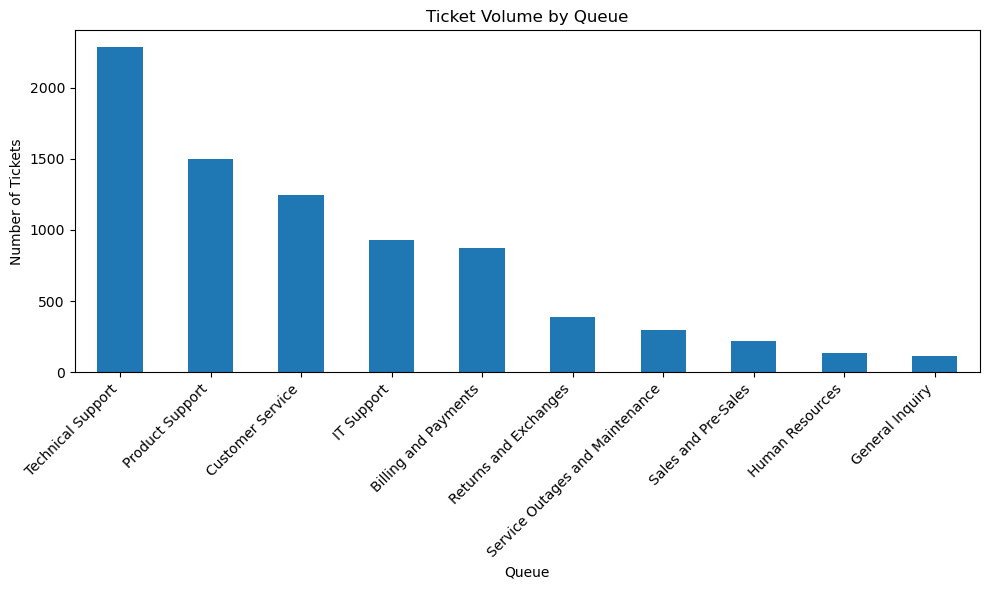

In [62]:
plt.figure(figsize=(10, 6))

queue_counts.plot(kind="bar")

plt.title("Ticket Volume by Queue")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [63]:
priority_counts = df_sample["priority"].value_counts()

priority_counts

priority
medium    3338
high      3058
low       1604
Name: count, dtype: int64

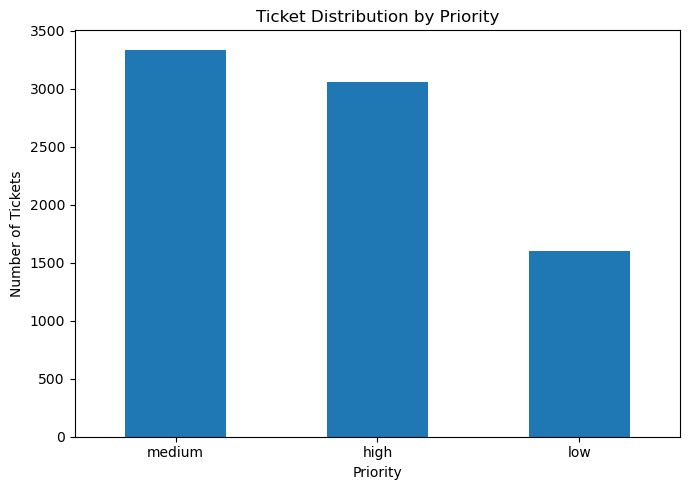

In [64]:
plt.figure(figsize=(7, 5))

priority_counts.plot(kind="bar")

plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [65]:
high_priority_by_queue = (
    df_sample[df_sample["priority"] == "high"]["queue"]
    .value_counts()
)

high_priority_by_queue

queue
Technical Support                  1299
Product Support                     470
IT Support                          432
Billing and Payments                246
Customer Service                    230
Service Outages and Maintenance     212
Returns and Exchanges                92
Sales and Pre-Sales                  46
General Inquiry                      16
Human Resources                      15
Name: count, dtype: int64

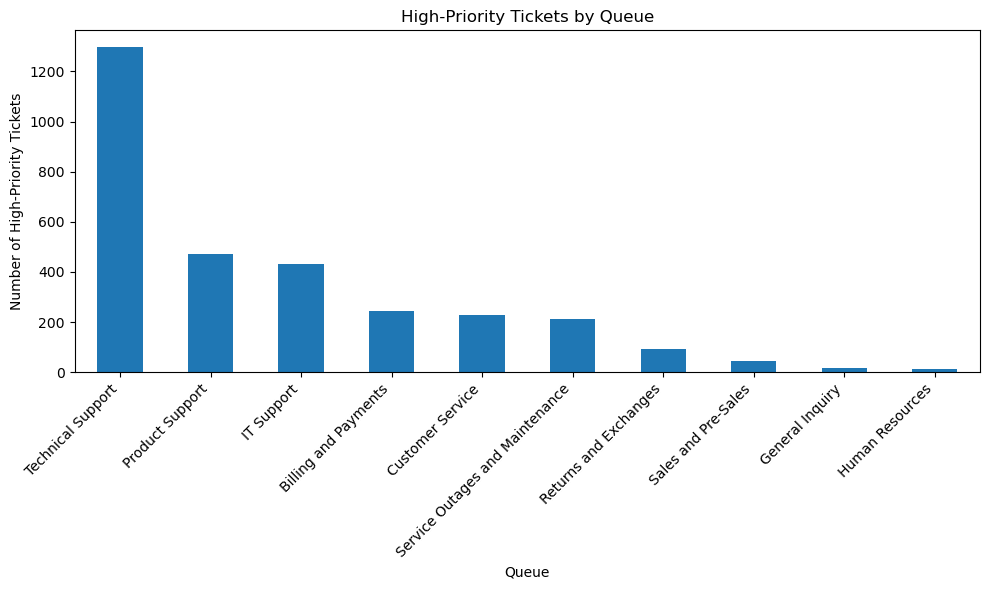

In [66]:
plt.figure(figsize=(10, 6))

high_priority_by_queue.plot(kind="bar")

plt.title("High-Priority Tickets by Queue")
plt.xlabel("Queue")
plt.ylabel("Number of High-Priority Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [67]:
high_priority_rate = (
    df_sample.assign(is_high=df_sample["priority"].eq("high"))
    .groupby("queue")["is_high"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

high_priority_rate.round(1)

queue
Service Outages and Maintenance    71.4
Technical Support                  56.7
IT Support                         46.3
Product Support                    31.4
Billing and Payments               28.2
Returns and Exchanges              23.5
Sales and Pre-Sales                20.8
Customer Service                   18.4
General Inquiry                    14.2
Human Resources                    10.9
Name: is_high, dtype: float64

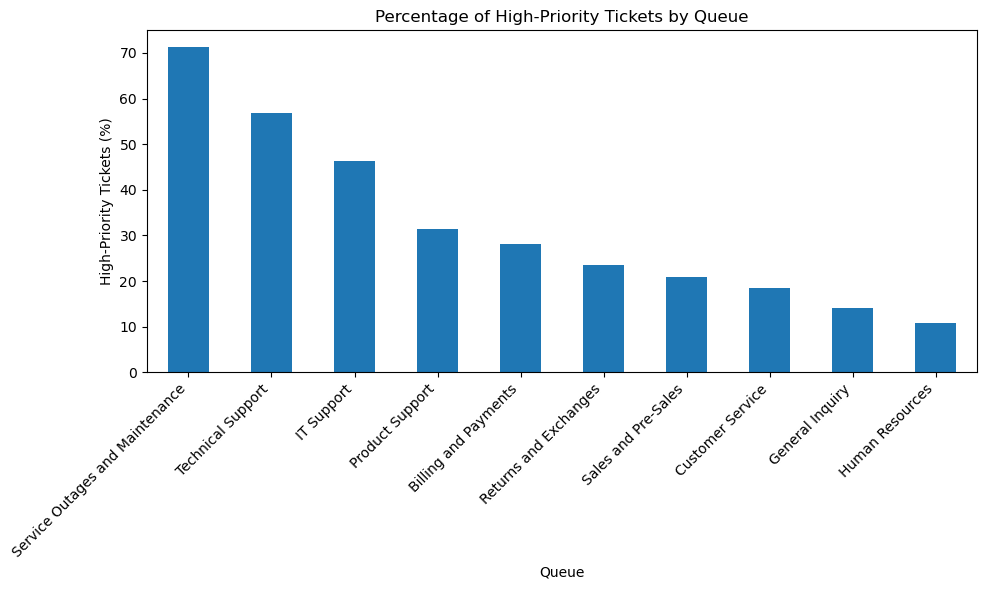

In [68]:
plt.figure(figsize=(10, 6))

high_priority_rate.plot(kind="bar")

plt.title("Percentage of High-Priority Tickets by Queue")
plt.xlabel("Queue")
plt.ylabel("High-Priority Tickets (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [69]:
df_sample["answer_word_count"] = (
    df_sample["answer"]
    .str.split()
    .str.len()
)

df_sample[["answer", "answer_word_count"]].head()

,answer,answer_word_count
0,I am here to assist you in resolving the techn...,60
1,"Dear [Customer Name],\n\nI am writing to ackno...",163
2,We will investigate the issue and can be conta...,30
3,We are taking this issue very seriously and wi...,32
4,"Hello <name>, thank you for contacting us abou...",81


In [70]:
avg_answer_length = (
    df_sample.groupby("queue")["answer_word_count"]
    .mean()
    .sort_values(ascending=False)
)

avg_answer_length.round(1)

queue
Human Resources                    62.8
Sales and Pre-Sales                62.7
General Inquiry                    62.6
Product Support                    62.2
IT Support                         61.8
Service Outages and Maintenance    61.2
Billing and Payments               60.6
Technical Support                  60.3
Customer Service                   58.4
Returns and Exchanges              58.2
Name: answer_word_count, dtype: float64

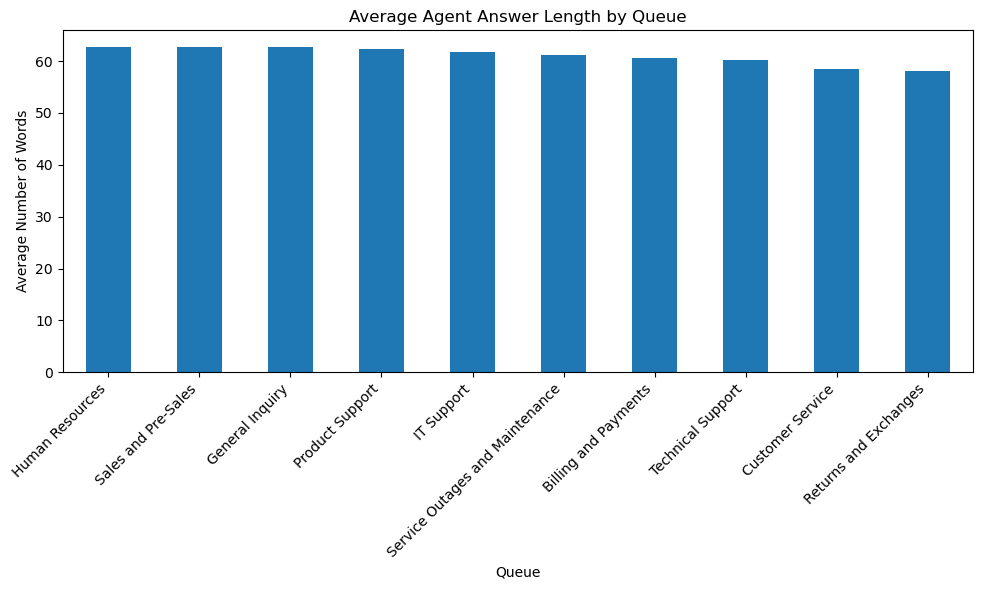

In [71]:
plt.figure(figsize=(10, 6))

avg_answer_length.plot(kind="bar")

plt.title("Average Agent Answer Length by Queue")
plt.xlabel("Queue")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

for queue in df_sample["queue"].unique():
    texts = df_sample.loc[
        df_sample["queue"] == queue, "body"
    ]

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=10
    )

    X = vectorizer.fit_transform(texts)

    print(f"\n{queue}:")
    print(", ".join(vectorizer.get_feature_names_out()))


Product Support:
appreciate, assistance, customer, data, information, issue, problem, provide, software, support

Customer Service:
appreciate, assistance, customer, data, greatly, information, issue, provide, support, tools

Sales and Pre-Sales:
analytics, appreciate, assistance, customer, data, information, investment, provide, support, tools

Billing and Payments:
appreciate, billing, customer, data, details, information, issue, payment, provide, support

Technical Support:
appreciate, assistance, customer, data, information, issue, problem, provide, software, support

Human Resources:
appreciate, assistance, customer, data, digital, information, issue, provide, software, support

Service Outages and Maintenance:
appreciate, assistance, customer, data, information, issue, medical, provide, service, support

IT Support:
appreciate, assistance, customer, data, information, issue, problem, provide, software, support

Returns and Exchanges:
appreciate, assistance, customer, data, infor

In [73]:
custom_stop_words = [
    "customer", "support", "assistance", "provide",
    "information", "issue", "appreciate", "data"
]

for queue in df_sample["queue"].unique():

    texts = df_sample.loc[
        df_sample["queue"] == queue, "body"
    ]

    vectorizer = TfidfVectorizer(
        stop_words=list(TfidfVectorizer(stop_words="english")
                        .get_stop_words()) + custom_stop_words,
        max_features=10
    )

    X = vectorizer.fit_transform(texts)

    print(f"\n{queue}:")
    print(", ".join(vectorizer.get_feature_names_out()))


Product Support:
analytics, br, greatly, integration, investment, medical, problem, security, software, tools

Customer Service:
analytics, forward, greatly, integration, investment, medical, security, software, thank, tools

Sales and Pre-Sales:
analytics, details, digital, greatly, integration, investment, medical, security, thank, tools

Billing and Payments:
billing, details, forward, greatly, look, medical, payment, response, services, thank

Technical Support:
analytics, br, greatly, help, integration, medical, problem, project, security, software

Human Resources:
analytics, digital, employee, help, marketing, problem, software, strategies, thank, training

Service Outages and Maintenance:
greatly, look, matter, medical, problem, security, server, service, software, tools

IT Support:
greatly, help, integration, medical, problem, project, security, software, thank, tools

Returns and Exchanges:
analytics, details, greatly, integration, investment, medical, problem, security, so

In [74]:
df_sample["text"] = (
    df_sample["subject"].fillna("") + " " +
    df_sample["body"].fillna("")
)

df_sample[["subject", "body", "text"]].head()

,subject,body,text
0,Technical Glitch Impairing Brand Expansion,"Issue: The campaign experienced a malfunction,...",Technical Glitch Impairing Brand Expansion Iss...
1,Acknowledgment of Data Breach Concern and Requ...,"Dear [Customer Name],\n\nI am writing to ackno...",Acknowledgment of Data Breach Concern and Requ...
2,Trouble with Periodic Connection Problems on O...,Currently facing periodic connection problems ...,Trouble with Periodic Connection Problems on O...
3,Concern Regarding Medical Information Security,We've identified a potential security breach i...,Concern Regarding Medical Information Security...
4,Integration of IBM SPSS Statistics 28 for Inve...,Which analytics tools can be integrated with I...,Integration of IBM SPSS Statistics 28 for Inve...


In [75]:
X = df_sample["text"]
y = df_sample["queue"]

print("Number of tickets:", len(X))
print("Number of queues:", y.nunique())
print(y.value_counts())

Number of tickets: 8000
Number of queues: 10
queue
Technical Support                  2289
Product Support                    1497
Customer Service                   1248
IT Support                          933
Billing and Payments                873
Returns and Exchanges               391
Service Outages and Maintenance     297
Sales and Pre-Sales                 221
Human Resources                     138
General Inquiry                     113
Name: count, dtype: int64


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training tickets:", len(X_train))
print("Testing tickets:", len(X_test))

Training tickets: 6400
Testing tickets: 1600


In [77]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train.to_frame(), y_train)

dummy_predictions = dummy_model.predict(X_test.to_frame())

dummy_accuracy = accuracy_score(y_test, dummy_predictions)
dummy_f1 = f1_score(
    y_test,
    dummy_predictions,
    average="macro"
)

print("Majority Baseline Accuracy:", round(dummy_accuracy, 4))
print("Majority Baseline Macro-F1:", round(dummy_f1, 4))

Majority Baseline Accuracy: 0.2863
Majority Baseline Macro-F1: 0.0445


In [78]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

queue_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [79]:
queue_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [80]:
queue_predictions = queue_model.predict(X_test)

In [81]:
queue_accuracy = accuracy_score(
    y_test,
    queue_predictions
)

queue_macro_f1 = f1_score(
    y_test,
    queue_predictions,
    average="macro"
)

print("TF-IDF + Logistic Regression Accuracy:",
      round(queue_accuracy, 4))

print("TF-IDF + Logistic Regression Macro-F1:",
      round(queue_macro_f1, 4))

TF-IDF + Logistic Regression Accuracy: 0.4381
TF-IDF + Logistic Regression Macro-F1: 0.2793


In [82]:
print("=== Model Comparison ===")

print("\nMajority Baseline")
print("Accuracy:", round(dummy_accuracy, 4))
print("Macro-F1:", round(dummy_f1, 4))

print("\nTF-IDF + Logistic Regression")
print("Accuracy:", round(queue_accuracy, 4))
print("Macro-F1:", round(queue_macro_f1, 4))

=== Model Comparison ===

Majority Baseline
Accuracy: 0.2863
Macro-F1: 0.0445

TF-IDF + Logistic Regression
Accuracy: 0.4381
Macro-F1: 0.2793


In [83]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        queue_predictions,
        zero_division=0
    )
)

                                 precision    recall  f1-score   support

           Billing and Payments       0.88      0.62      0.72       175
               Customer Service       0.35      0.38      0.36       250
                General Inquiry       0.00      0.00      0.00        23
                Human Resources       1.00      0.04      0.07        28
                     IT Support       0.54      0.13      0.22       186
                Product Support       0.36      0.31      0.34       299
          Returns and Exchanges       1.00      0.03      0.05        78
            Sales and Pre-Sales       1.00      0.02      0.04        44
Service Outages and Maintenance       0.90      0.31      0.46        59
              Technical Support       0.41      0.78      0.54       458

                       accuracy                           0.44      1600
                      macro avg       0.64      0.26      0.28      1600
                   weighted avg       0.52      0

<Figure size 1200x1000 with 0 Axes>

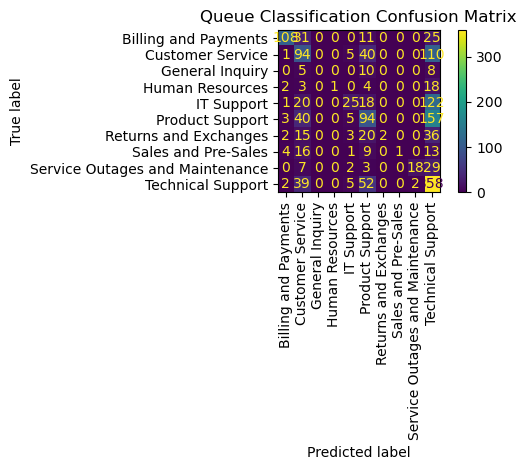

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    queue_predictions,
    xticks_rotation=90
)

plt.title("Queue Classification Confusion Matrix")
plt.tight_layout()
plt.show()

In [85]:
X_priority = df_sample["text"]
y_priority = df_sample["priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_priority,
    y_priority,
    test_size=0.20,
    random_state=42,
    stratify=y_priority
)

print("Training tickets:", len(X_train_p))
print("Testing tickets:", len(X_test_p))

print("\nPriority distribution:")
print(y_train_p.value_counts())

Training tickets: 6400
Testing tickets: 1600

Priority distribution:
priority
medium    2671
high      2446
low       1283
Name: count, dtype: int64


In [86]:
priority_dummy = DummyClassifier(strategy="most_frequent")

priority_dummy.fit(
    X_train_p.to_frame(),
    y_train_p
)

priority_dummy_predictions = priority_dummy.predict(
    X_test_p.to_frame()
)

priority_dummy_accuracy = accuracy_score(
    y_test_p,
    priority_dummy_predictions
)

priority_dummy_f1 = f1_score(
    y_test_p,
    priority_dummy_predictions,
    average="macro"
)

print("Priority Baseline Accuracy:",
      round(priority_dummy_accuracy, 4))

print("Priority Baseline Macro-F1:",
      round(priority_dummy_f1, 4))

Priority Baseline Accuracy: 0.4169
Priority Baseline Macro-F1: 0.1961


In [87]:
priority_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

priority_model.fit(X_train_p, y_train_p)

priority_predictions = priority_model.predict(X_test_p)

In [88]:
priority_accuracy = accuracy_score(
    y_test_p,
    priority_predictions
)

priority_macro_f1 = f1_score(
    y_test_p,
    priority_predictions,
    average="macro"
)

print("=== Priority Model Comparison ===")

print("\nMajority Baseline")
print("Accuracy:", round(priority_dummy_accuracy, 4))
print("Macro-F1:", round(priority_dummy_f1, 4))

print("\nTF-IDF + Logistic Regression")
print("Accuracy:", round(priority_accuracy, 4))
print("Macro-F1:", round(priority_macro_f1, 4))

=== Priority Model Comparison ===

Majority Baseline
Accuracy: 0.4169
Macro-F1: 0.1961

TF-IDF + Logistic Regression
Accuracy: 0.5356
Macro-F1: 0.457


In [97]:
!pip install torch transformers datasets accelerate

In [98]:
import torch
import transformers

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())
!pip install torch transformers datasets accelerate

PyTorch version: 2.14.0+cpu
Transformers version: 5.16.1
CUDA available: False


# RAG - Knowledge Base Preparation

In [99]:
# Prepare answers for the RAG knowledge base

rag_df = df_sample.copy()

rag_df = rag_df[
    rag_df["answer"].notna() &
    (rag_df["answer"].str.strip() != "")
].copy()

print("Tickets available for RAG:", len(rag_df))
print("\nSample answer:")
print(rag_df["answer"].iloc[0])

Tickets available for RAG: 8000

Sample answer:
I am here to assist you in resolving the technical glitch affecting your brand's expansion. To provide better support, I would like to delve into the specifics of the software integration issues you are encountering. Would you be available to discuss this further over a call at your earliest convenience, or would you prefer to send additional details via email?


In [100]:
# Split answers into chunks

def chunk_text(text, chunk_size=120):
    words = text.split()

    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        chunks.append(chunk)

    return chunks


rag_chunks = []

for idx, row in rag_df.iterrows():
    chunks = chunk_text(row["answer"])

    for chunk in chunks:
        rag_chunks.append({
            "ticket_id": idx,
            "queue": row["queue"],
            "priority": row["priority"],
            "text": chunk
        })


print("Total chunks:", len(rag_chunks))
print("\nFirst chunk:")
print(rag_chunks[0])

Total chunks: 8320

First chunk:
{'ticket_id': 0, 'queue': 'Product Support', 'priority': 'medium', 'text': "I am here to assist you in resolving the technical glitch affecting your brand's expansion. To provide better support, I would like to delve into the specifics of the software integration issues you are encountering. Would you be available to discuss this further over a call at your earliest convenience, or would you prefer to send additional details via email?"}


In [3]:
import pandas as pd

# Load the cleaned 8000-ticket dataset
df_sample = pd.read_csv("clean_tickets_8000.csv")

# Keep valid answers
rag_df = df_sample[
    df_sample["answer"].notna() &
    (df_sample["answer"].str.strip() != "")
].copy()

# Chunk answers
def chunk_text(text, chunk_size=120):
    words = text.split()
    return [
        " ".join(words[i:i + chunk_size])
        for i in range(0, len(words), chunk_size)
    ]

rag_chunks = []

for idx, row in rag_df.iterrows():
    for chunk in chunk_text(row["answer"]):
        rag_chunks.append({
            "ticket_id": idx,
            "queue": row["queue"],
            "priority": row["priority"],
            "text": chunk
        })

chunks_df = pd.DataFrame(rag_chunks)

print("Tickets:", len(rag_df))
print("Chunks:", len(chunks_df))

Tickets: 8000
Chunks: 8320


In [101]:
import pandas as pd

chunks_df = pd.DataFrame(rag_chunks)

print("Shape:", chunks_df.shape)
print("\nColumns:")
print(chunks_df.columns.tolist())

chunks_df.head()

Shape: (8320, 4)

Columns:
['ticket_id', 'queue', 'priority', 'text']


,ticket_id,queue,priority,text
0,0,Product Support,medium,I am here to assist you in resolving the techn...
1,1,Product Support,high,"Dear [Customer Name],\n\nI am writing to ackno..."
2,1,Product Support,high,reference number [Ref_Num] to your case and yo...
3,2,Customer Service,low,We will investigate the issue and can be conta...
4,3,Sales and Pre-Sales,medium,We are taking this issue very seriously and wi...


In [102]:
!pip install -q sentence-transformers faiss-cpu

In [104]:
!pip install --upgrade --force-reinstall pyarrow

  Using cached pyarrow-25.0.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
Using cached pyarrow-25.0.1-cp313-cp313-win_amd64.whl (27.9 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 25.0.1
    Uninstalling pyarrow-25.0.1:
      Successfully uninstalled pyarrow-25.0.1


In [1]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\CW\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CW\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded!


In [4]:
embeddings = embedding_model.encode(
    chunks_df["text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/260 [00:00<?, ?it/s]

Embeddings shape: (8320, 384)


In [5]:
import faiss
import numpy as np

# Convert embeddings to float32 because FAISS expects that
embeddings_f32 = embeddings.astype("float32")

# Create FAISS index
dimension = embeddings_f32.shape[1]
index = faiss.IndexFlatL2(dimension)

# Add embeddings to the index
index.add(embeddings_f32)

print("FAISS index created!")
print("Total vectors in index:", index.ntotal)

FAISS index created!
Total vectors in index: 8320


In [6]:
# Test semantic search

query = "I am having a problem with my payment"

query_embedding = embedding_model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")

distances, indices = index.search(query_embedding, k=3)

print("Query:", query)
print("\nTop 3 retrieved answers:\n")

for rank, idx in enumerate(indices[0], start=1):
    print(f"Result {rank}")
    print("Queue:", chunks_df.iloc[idx]["queue"])
    print("Priority:", chunks_df.iloc[idx]["priority"])
    print("Answer:", chunks_df.iloc[idx]["text"])
    print("Distance:", distances[0][rank - 1])
    print("-" * 80)

Query: I am having a problem with my payment

Top 3 retrieved answers:

Result 1
Queue: Billing and Payments
Priority: high
Answer: Hello <name>, we are sorry to hear that you are facing a payment processing problem. I am here to help you resolve this. To better understand the situation, could you please provide your <acc_num> and the date of the failed payment? If needed, I may contact you; please let me know a convenient time to call you at <tel_num>. I will get back to you with a solution as soon as possible.
Distance: 0.4422479
--------------------------------------------------------------------------------
Result 2
Queue: Billing and Payments
Priority: high
Answer: Dear <name>, I apologize for the payment failure issue you are facing. I am here to help resolve it. To better understand the situation, please provide your <acc_num> and the date of the failed payment. I may need to call you for further discussion. Please let me know a convenient time to contact you at <tel_num> for th

In [7]:
import faiss

# Save FAISS index
faiss.write_index(index, "tickets_faiss.index")

# Save chunk metadata
chunks_df.to_csv("rag_chunks.csv", index=False)

print("RAG files saved successfully!")

RAG files saved successfully!


In [8]:
def retrieve_answers(query, k=3):
    # Convert the user's question into an embedding
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")

    # Search FAISS
    distances, indices = index.search(query_embedding, k)

    results = []

    for distance, idx in zip(distances[0], indices[0]):
        row = chunks_df.iloc[idx]

        results.append({
            "ticket_id": int(row["ticket_id"]),
            "queue": row["queue"],
            "priority": row["priority"],
            "answer": row["text"],
            "distance": float(distance)
        })

    return results

In [9]:
results = retrieve_answers(
    "My payment keeps failing",
    k=3
)

for result in results:
    print(result)
    print("-" * 80)

{'ticket_id': 944, 'queue': 'Billing and Payments', 'priority': 'high', 'answer': 'Dear <name>, I apologize for the payment failure issue you are facing. I am here to help resolve it. To better understand the situation, please provide your <acc_num> and the date of the failed payment. I may need to call you for further discussion. Please let me know a convenient time to contact you at <tel_num> for this purpose. I will address this matter as soon as possible and provide you with a solution.', 'distance': 0.504346489906311}
--------------------------------------------------------------------------------
{'ticket_id': 4827, 'queue': 'Billing and Payments', 'priority': 'high', 'answer': 'Hello <name>, we are sorry to hear that you are facing a payment processing problem. I am here to help you resolve this. To better understand the situation, could you please provide your <acc_num> and the date of the failed payment? If needed, I may contact you; please let me know a convenient time to cal

In [10]:
def build_rag_context(query, k=3):
    results = retrieve_answers(query, k=k)

    context_parts = []

    for i, result in enumerate(results, start=1):
        context_parts.append(
            f"Source {i}:\n"
            f"Queue: {result['queue']}\n"
            f"Priority: {result['priority']}\n"
            f"Answer: {result['answer']}"
        )

    context = "\n\n".join(context_parts)

    return context

In [11]:
query = "My payment keeps failing"

context = build_rag_context(query)

print(context)

Source 1:
Queue: Billing and Payments
Priority: high
Answer: Dear <name>, I apologize for the payment failure issue you are facing. I am here to help resolve it. To better understand the situation, please provide your <acc_num> and the date of the failed payment. I may need to call you for further discussion. Please let me know a convenient time to contact you at <tel_num> for this purpose. I will address this matter as soon as possible and provide you with a solution.

Source 2:
Queue: Billing and Payments
Priority: high
Answer: Hello <name>, we are sorry to hear that you are facing a payment processing problem. I am here to help you resolve this. To better understand the situation, could you please provide your <acc_num> and the date of the failed payment? If needed, I may contact you; please let me know a convenient time to call you at <tel_num>. I will get back to you with a solution as soon as possible.

Source 3:
Queue: Billing and Payments
Priority: high
Answer: Dear <name>, I r

In [12]:
def build_rag_prompt(query, context):
    prompt = f"""
You are a customer support assistant.

Use only the information in the provided context to answer the user's question.
Do not invent information.
If the context does not contain enough information, say that more details are needed.

User question:
{query}

Context:
{context}

Answer:
"""
    return prompt


query = "My payment keeps failing"
context = build_rag_context(query)

prompt = build_rag_prompt(query, context)

print(prompt)


You are a customer support assistant.

Use only the information in the provided context to answer the user's question.
Do not invent information.
If the context does not contain enough information, say that more details are needed.

User question:
My payment keeps failing

Context:
Source 1:
Queue: Billing and Payments
Priority: high
Answer: Dear <name>, I apologize for the payment failure issue you are facing. I am here to help resolve it. To better understand the situation, please provide your <acc_num> and the date of the failed payment. I may need to call you for further discussion. Please let me know a convenient time to contact you at <tel_num> for this purpose. I will address this matter as soon as possible and provide you with a solution.

Source 2:
Queue: Billing and Payments
Priority: high
Answer: Hello <name>, we are sorry to hear that you are facing a payment processing problem. I am here to help you resolve this. To better understand the situation, could you please provid

In [13]:
!pip install -q openai python-dotenv

In [20]:
from getpass import getpass
from pathlib import Path

gemini_key = getpass("Paste your Gemini API key here: ")

with open(".env", "a", encoding="utf-8") as f:
    f.write(f"\nGEMINI_API_KEY={gemini_key}\n")

print("Gemini API key saved safely!")

Paste your Gemini API key here:  ········


Gemini API key saved safely!


In [21]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

gemini_key = os.getenv("GEMINI_API_KEY")

if gemini_key:
    print("Gemini API key loaded successfully!")
else:
    print("Gemini API key not found.")

Gemini API key loaded successfully!


In [22]:
!pip install -q google-genai

  You can safely remove it manually.


In [23]:
from google import genai

print("Gemini library imported successfully!")

Gemini library imported successfully!


In [25]:
from getpass import getpass

gemini_key = getpass("Paste the NEW Gemini API key: ").strip()

print("Key received:", bool(gemini_key))
print("Key length:", len(gemini_key))

Paste the NEW Gemini API key:  ········


Key received: True
Key length: 245


In [27]:

from getpass import getpass

test_key = getpass("Paste copied Gemini key: ").strip()

print("Starts with:", test_key[:4])
print("Length:", len(test_key))

Paste copied Gemini key:  ········


Starts with: AQ.A
Length: 53


In [29]:
from google import genai

client = genai.Client(api_key=test_key)

response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="Say exactly: Gemini connection works!"
)

print(response.text)

Gemini connection works!


In [30]:
from pathlib import Path

env_path = Path(".env")

env_path.write_text(
    f"GEMINI_API_KEY={test_key}\n",
    encoding="utf-8"
)

print("Correct Gemini API key saved!")

Correct Gemini API key saved!


In [31]:
def rag_answer(query, k=3):
    # 1. Retrieve relevant answers from FAISS
    context = build_rag_context(query, k=k)

    # 2. Build the RAG prompt
    prompt = build_rag_prompt(query, context)

    # 3. Send context + question to Gemini
    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    return response.text

In [32]:
query = "My payment keeps failing"

answer = rag_answer(query)

print("User:", query)
print("\nRAG Assistant:")
print(answer)

User: My payment keeps failing

RAG Assistant:
I apologize for the payment failure issue you are facing, and I am here to help resolve it. 

To better understand the situation and provide a solution as soon as possible, please provide:
1. Your account number (`<acc_num>`).
2. The date of the failed payment.
3. A convenient time for us to call you at your telephone number (`<tel_num>`) if further discussion is needed.


In [33]:
# Conversation Memory

conversation_memory = {}

def add_to_memory(session_id, role, message):
    if session_id not in conversation_memory:
        conversation_memory[session_id] = []

    conversation_memory[session_id].append({
        "role": role,
        "message": message
    })

def get_memory(session_id):
    return conversation_memory.get(session_id, [])

In [34]:
add_to_memory("user_1", "user", "My payment keeps failing")
add_to_memory("user_1", "assistant", "When did the payment fail?")
add_to_memory("user_1", "user", "It happened yesterday")

print(get_memory("user_1"))

[{'role': 'user', 'message': 'My payment keeps failing'}, {'role': 'assistant', 'message': 'When did the payment fail?'}, {'role': 'user', 'message': 'It happened yesterday'}]


In [35]:
# Tool 1: Knowledge Base Search

def knowledge_base_search(query, k=3):
    results = retrieve_answers(query, k=k)

    return {
        "tool": "knowledge_base_search",
        "query": query,
        "results": results
    }

In [36]:
test_tool = knowledge_base_search(
    "My payment keeps failing"
)

print("Tool:", test_tool["tool"])

for result in test_tool["results"]:
    print("\nQueue:", result["queue"])
    print("Priority:", result["priority"])
    print("Answer:", result["answer"])

Tool: knowledge_base_search

Queue: Billing and Payments
Priority: high
Answer: Dear <name>, I apologize for the payment failure issue you are facing. I am here to help resolve it. To better understand the situation, please provide your <acc_num> and the date of the failed payment. I may need to call you for further discussion. Please let me know a convenient time to contact you at <tel_num> for this purpose. I will address this matter as soon as possible and provide you with a solution.

Queue: Billing and Payments
Priority: high
Answer: Hello <name>, we are sorry to hear that you are facing a payment processing problem. I am here to help you resolve this. To better understand the situation, could you please provide your <acc_num> and the date of the failed payment? If needed, I may contact you; please let me know a convenient time to call you at <tel_num>. I will get back to you with a solution as soon as possible.

Queue: Billing and Payments
Priority: high
Answer: Dear <name>, I re

In [37]:
variables_to_check = [
    "queue_model",
    "priority_model",
    "tfidf",
    "queue_vectorizer",
    "priority_vectorizer"
]

for var in variables_to_check:
    print(var, ":", var in globals())

queue_model : False
priority_model : False
tfidf : False
queue_vectorizer : False
priority_vectorizer : False


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Prepare text
df_sample["text"] = (
    df_sample["subject"].fillna("") + " " +
    df_sample["body"].fillna("")
)

# Queue model
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    df_sample["text"],
    df_sample["queue"],
    test_size=0.2,
    random_state=42,
    stratify=df_sample["queue"]
)

queue_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000))
])

queue_model.fit(X_train_q, y_train_q)

print("Queue model trained!")

Queue model trained!


In [39]:
# Priority model

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    df_sample["text"],
    df_sample["priority"],
    test_size=0.2,
    random_state=42,
    stratify=df_sample["priority"]
)

priority_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000))
])

priority_model.fit(X_train_p, y_train_p)

print("Priority model trained!")

Priority model trained!


In [40]:
import joblib

joblib.dump(queue_model, "queue_model.joblib")
joblib.dump(priority_model, "priority_model.joblib")

print("Models saved successfully!")

Models saved successfully!


In [41]:
# Tool 2: Ticket Triage

def ticket_triage(ticket_text):
    predicted_queue = queue_model.predict([ticket_text])[0]
    predicted_priority = priority_model.predict([ticket_text])[0]

    return {
        "tool": "ticket_triage",
        "queue": predicted_queue,
        "priority": predicted_priority
    }

In [42]:
test_ticket = "My payment keeps failing and I cannot complete the transaction"

triage_result = ticket_triage(test_ticket)

print("Tool:", triage_result["tool"])
print("Predicted Queue:", triage_result["queue"])
print("Predicted Priority:", triage_result["priority"])

Tool: ticket_triage
Predicted Queue: Billing and Payments
Predicted Priority: high


In [43]:
def support_agent(session_id, user_message):
    # Save user message
    add_to_memory(session_id, "user", user_message)

    # Tool 1: Triage
    triage = ticket_triage(user_message)

    # Tool 2: Knowledge Base Search
    kb_results = knowledge_base_search(user_message, k=3)

    # Build context from retrieved answers
    context_parts = []

    for i, result in enumerate(kb_results["results"], start=1):
        context_parts.append(
            f"Source {i}:\n"
            f"Queue: {result['queue']}\n"
            f"Priority: {result['priority']}\n"
            f"Answer: {result['answer']}"
        )

    context = "\n\n".join(context_parts)

    # Get conversation history
    history = get_memory(session_id)

    history_text = "\n".join(
        [f"{item['role']}: {item['message']}" for item in history]
    )

    prompt = f"""
You are a customer support assistant.

Predicted ticket queue:
{triage['queue']}

Predicted priority:
{triage['priority']}

Conversation history:
{history_text}

Knowledge base:
{context}

Answer the user's latest message using the knowledge base.
Use the conversation history when needed.
Do not invent information.
If more details are needed, ask the user clearly.

User message:
{user_message}

Answer:
"""

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    answer = response.text

    # Save assistant response
    add_to_memory(session_id, "assistant", answer)

    return {
        "queue": triage["queue"],
        "priority": triage["priority"],
        "answer": answer
    }

In [44]:
result1 = support_agent(
    "test_user",
    "My payment keeps failing."
)

print("Queue:", result1["queue"])
print("Priority:", result1["priority"])
print("\nAssistant:")
print(result1["answer"])

Queue: Billing and Payments
Priority: medium

Assistant:
Hello <name>,

I am sorry to hear that you are facing a payment processing problem. I am here to help you resolve this. 

To better understand the situation, could you please provide your <acc_num> and the date of the failed payment? If further discussion is needed, I may contact you, so please also let me know a convenient time to call you at <tel_num>.

I will address this matter as soon as possible and get back to you with a solution.


In [45]:
result2 = support_agent(
    "test_user",
    "It happened yesterday."
)

print("Queue:", result2["queue"])
print("Priority:", result2["priority"])
print("\nAssistant:")
print(result2["answer"])

Queue: Technical Support
Priority: high

Assistant:
Thank you for providing the date. 

To help us investigate this further and resolve the issue as quickly as possible, could you please also provide your account number (`<acc_num>`) and a convenient time for us to contact you at `<tel_num>`?


In [46]:
def clean_answer_text(text):
    replacements = {
        "<name>": "there",
        "<acc_num>": "account number",
        "<tel_num>": "phone number"
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text

In [47]:
test_text = "Hello <name>, please provide your <acc_num> and <tel_num>."
print(clean_answer_text(test_text))

Hello there, please provide your account number and phone number.


In [48]:
def support_agent_v2(session_id, user_message):

    # Get previous conversation BEFORE adding new message
    previous_history = get_memory(session_id)

    # Build context-aware text for tools
    previous_user_messages = [
        item["message"]
        for item in previous_history
        if item["role"] == "user"
    ]

    tool_text = " ".join(previous_user_messages + [user_message])

    # Save current user message
    add_to_memory(session_id, "user", user_message)

    # Tool 1: Triage using conversation context
    triage = ticket_triage(tool_text)

    # Tool 2: Knowledge search using conversation context
    kb_results = knowledge_base_search(tool_text, k=3)

    context_parts = []

    for i, result in enumerate(kb_results["results"], start=1):
        context_parts.append(
            f"Source {i}:\n"
            f"Queue: {result['queue']}\n"
            f"Priority: {result['priority']}\n"
            f"Answer: {clean_answer_text(result['answer'])}"
        )

    context = "\n\n".join(context_parts)

    # Full conversation history
    history = get_memory(session_id)

    history_text = "\n".join(
        f"{item['role']}: {item['message']}"
        for item in history
    )

    prompt = f"""
You are a customer support assistant.

Predicted queue:
{triage['queue']}

Predicted priority:
{triage['priority']}

Conversation history:
{history_text}

Knowledge base:
{context}

Answer the user's latest message using the knowledge base
and conversation history.

Do not invent information.
Do not use placeholders such as <name>, <acc_num>, or <tel_num>.
If more information is needed, ask clearly.

Latest user message:
{user_message}

Answer:
"""

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    answer = clean_answer_text(response.text)

    add_to_memory(session_id, "assistant", answer)

    return {
        "queue": triage["queue"],
        "priority": triage["priority"],
        "answer": answer
    }

In [49]:
result1 = support_agent_v2(
    "test_user_v2",
    "My payment keeps failing."
)

print("Queue:", result1["queue"])
print("Priority:", result1["priority"])
print("\nAssistant:")
print(result1["answer"])

Queue: Billing and Payments
Priority: medium

Assistant:
Hello, I am sorry to hear that you are facing a payment failure issue. I am here to help you resolve this. 

To better understand the situation, could you please provide your account number and the date of the failed payment? Additionally, if further discussion is needed, please let me know your phone number and a convenient time for us to call you. 

I will look into this matter as soon as possible and get back to you with a solution.


In [50]:
result2 = support_agent_v2(
    "test_user_v2",
    "It happened yesterday."
)

print("Queue:", result2["queue"])
print("Priority:", result2["priority"])
print("\nAssistant:")
print(result2["answer"])

Queue: Billing and Payments
Priority: high

Assistant:
Thank you for providing the date. 

To help me look into this issue and assist you further, could you please also provide your account number? Additionally, please let me know your phone number and a convenient time for me to call you if further discussion is needed.


In [51]:
!pip install -q fastapi uvicorn

In [52]:
import os

os.makedirs("ticket_support_app", exist_ok=True)

print("Project folder created!")

Project folder created!


In [53]:
import os

print(os.listdir())

['.anaconda', '.cache', '.conda', '.condarc', '.continuum', '.env', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.m2', '.matplotlib', '.ms-ad', '.nbi', '.packettracer', '.VirtualBox', '.virtual_documents', '01_the_machine_learning_landscape.ipynb', '02_end_to_end_machine_learning_project.ipynb', '03_classification.ipynb', '04_training_linear_models.ipynb', '05_support_vector_machines.ipynb', '06_decision_trees.ipynb', '3D Objects', 'age_distribution.png', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'assignment1 (4).ipynb', 'assignment1.ipynb', 'Assignment2.ipynb', 'Assignment2_TeenSmartphone.ipynb', 'assignment5.ipynb', 'average_salary_by_department.png', 'average_salary_department_gender.png', 'Cisco Packet Tracer 8.2.2', 'clean_tickets_8000.csv', 'Contacts', 'Cookies', 'correlation_heatmap.png', 'data_cleaning.ipynb', 'Desktop', 'Diabetes_NN_Lab.ipynb', 'Divvy_Trips_new.csv', 'Documents', 'Downloads', 'electric.log', 'Employee Sample Data.ipynb', 'Emp

In [54]:
import shutil
import os

files_to_copy = [
    "queue_model.joblib",
    "priority_model.joblib",
    "tickets_faiss.index",
    "rag_chunks.csv"
]

for file in files_to_copy:
    shutil.copy(file, "ticket_support_app")

print(os.listdir("ticket_support_app"))

['priority_model.joblib', 'queue_model.joblib', 'rag_chunks.csv', 'tickets_faiss.index']


In [55]:
import shutil

shutil.copy(".env", "ticket_support_app/.env")

print(".env copied safely!")

.env copied safely!


In [56]:
main_code = r'''
from fastapi import FastAPI
from pydantic import BaseModel
from dotenv import load_dotenv

import os
import joblib
import pandas as pd
import faiss
from sentence_transformers import SentenceTransformer
from google import genai

# -----------------------------
# Setup
# -----------------------------

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
load_dotenv(os.path.join(BASE_DIR, ".env"))

app = FastAPI(
    title="Customer Support Ticket Intelligence API",
    version="1.0.0"
)

# -----------------------------
# Load models and RAG files
# -----------------------------

queue_model = joblib.load(
    os.path.join(BASE_DIR, "queue_model.joblib")
)

priority_model = joblib.load(
    os.path.join(BASE_DIR, "priority_model.joblib")
)

chunks_df = pd.read_csv(
    os.path.join(BASE_DIR, "rag_chunks.csv")
)

index = faiss.read_index(
    os.path.join(BASE_DIR, "tickets_faiss.index")
)

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

gemini_client = genai.Client(
    api_key=os.getenv("GEMINI_API_KEY")
)

conversation_memory = {}

# -----------------------------
# Request models
# -----------------------------

class TriageRequest(BaseModel):
    text: str


class ChatRequest(BaseModel):
    session_id: str
    message: str


# -----------------------------
# Helper functions
# -----------------------------

def clean_answer_text(text):
    replacements = {
        "<name>": "there",
        "<acc_num>": "account number",
        "<tel_num>": "phone number"
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text


def add_to_memory(session_id, role, message):
    if session_id not in conversation_memory:
        conversation_memory[session_id] = []

    conversation_memory[session_id].append({
        "role": role,
        "message": message
    })


def get_memory(session_id):
    return conversation_memory.get(session_id, [])


def ticket_triage(ticket_text):
    queue = queue_model.predict([ticket_text])[0]
    priority = priority_model.predict([ticket_text])[0]

    return {
        "queue": queue,
        "priority": priority
    }


def retrieve_answers(query, k=3):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    ).astype("float32")

    distances, indices = index.search(
        query_embedding,
        k
    )

    results = []

    for distance, idx in zip(
        distances[0],
        indices[0]
    ):
        row = chunks_df.iloc[idx]

        results.append({
            "ticket_id": int(row["ticket_id"]),
            "queue": row["queue"],
            "priority": row["priority"],
            "answer": clean_answer_text(row["text"]),
            "distance": float(distance)
        })

    return results


def support_agent(session_id, user_message):

    previous_history = get_memory(session_id)

    previous_user_messages = [
        item["message"]
        for item in previous_history
        if item["role"] == "user"
    ]

    tool_text = " ".join(
        previous_user_messages + [user_message]
    )

    add_to_memory(
        session_id,
        "user",
        user_message
    )

    triage = ticket_triage(tool_text)

    kb_results = retrieve_answers(
        tool_text,
        k=3
    )

    context_parts = []

    for i, result in enumerate(
        kb_results,
        start=1
    ):
        context_parts.append(
            f"""Source {i}:
Queue: {result['queue']}
Priority: {result['priority']}
Answer: {result['answer']}"""
        )

    context = "\n\n".join(context_parts)

    history = get_memory(session_id)

    history_text = "\n".join(
        f"{item['role']}: {item['message']}"
        for item in history
    )

    prompt = f"""
You are a customer support assistant.

Predicted queue:
{triage['queue']}

Predicted priority:
{triage['priority']}

Conversation history:
{history_text}

Knowledge base:
{context}

Answer the user's latest message using the knowledge base
and conversation history.

Do not invent information.
Do not use placeholders such as <name>, <acc_num>, or <tel_num>.
If more information is needed, ask clearly.

Latest user message:
{user_message}

Answer:
"""

    response = gemini_client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    answer = clean_answer_text(
        response.text
    )

    add_to_memory(
        session_id,
        "assistant",
        answer
    )

    return {
        "queue": triage["queue"],
        "priority": triage["priority"],
        "answer": answer
    }


# -----------------------------
# API endpoints
# -----------------------------

@app.get("/")
def home():
    return {
        "message": "Customer Support API is running"
    }


@app.post("/triage")
def triage_endpoint(request: TriageRequest):
    return ticket_triage(
        request.text
    )


@app.post("/chat")
def chat_endpoint(request: ChatRequest):
    return support_agent(
        request.session_id,
        request.message
    )
'''

with open(
    "ticket_support_app/main.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(main_code)

print("main.py created successfully!")

main.py created successfully!


In [57]:
import os

print(os.listdir("ticket_support_app"))

['.env', 'main.py', 'priority_model.joblib', 'queue_model.joblib', 'rag_chunks.csv', 'tickets_faiss.index']


In [58]:
%cd ticket_support_app

C:\Users\CW\ticket_support_app


In [59]:
!uvicorn main:app --reload

^C


In [60]:
!uvicorn main:app --host 127.0.0.1 --port 8000


Loading weights: 100%|##########| 103/103 [00:00<00:00, 5476.29it/s]
INFO:     Started server process [5280]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [61]:
!uvicorn main:app --host 127.0.0.1 --port 8001

^C
